In [1]:
# Install the Groq SDK
!pip install -q -U groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.7/139.7 kB 3.2 MB/s eta 0:00:00


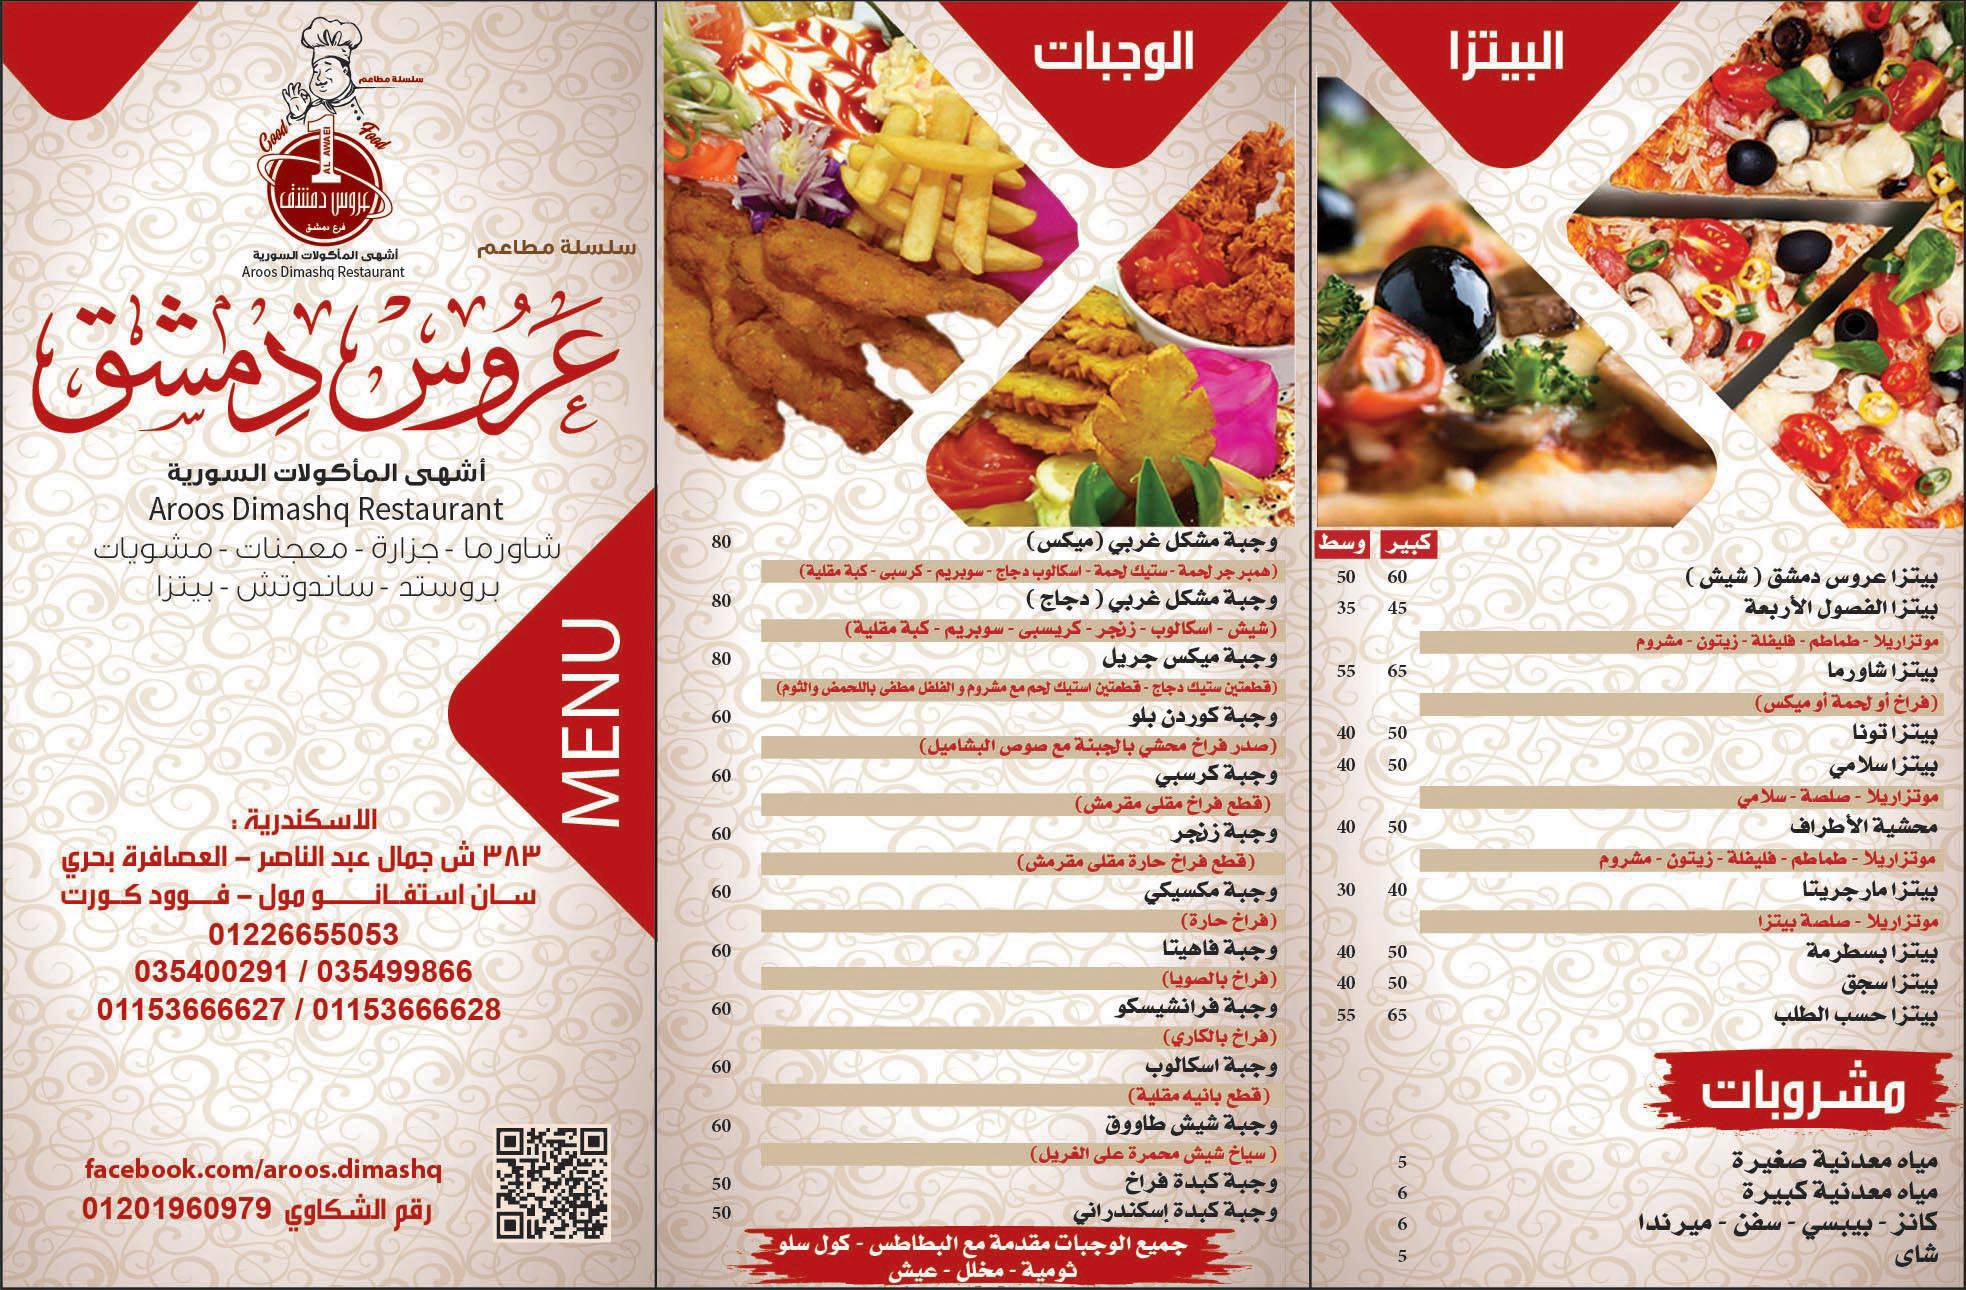

In [2]:
import os
import base64
import json
from groq import Groq
from google.colab import userdata
from IPython.display import Image as IPImage, display

# 1. Securely load the API key from Colab Secrets
api_key = userdata.get('GROQ_API_KEY')
client = Groq(api_key=api_key)

# 2. Define path and display the original image
sample_image_path = '/content/عروس.jpg' # Replace with your exact filename
display(IPImage(filename=sample_image_path))

In [3]:
# 3. Groq Vision requires images to be passed as base64 encoded URLs
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

base64_image = encode_image(sample_image_path)

In [5]:
# 4. Define the strict extraction prompt
prompt = """
Extract all menu items and their corresponding prices from this image.
Return the result strictly as a JSON array of objects.
Use the keys "item_name" and "price".
Keep the original language of the text exactly as it appears in the image (Arabic remains Arabic, English remains English). Do not translate.
"""

# 5. Call the API using Llama 3.2 Vision
response = client.chat.completions.create(
    model="meta-llama/llama-4-scout-17b-16e-instruct", # You can also use "llama-3.2-90b-vision-preview"
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/jpeg;base64,{base64_image}",
                    },
                },
            ],
        }
    ],
    temperature=0, # Keep it deterministic for OCR
    response_format={"type": "json_object"} # Enforce JSON output
)

In [6]:
# 6. Parse and print the result with UTF-8 support for Arabic characters
try:
    # Groq returns the content inside the choices array
    raw_content = response.choices[0].message.content
    menu_data = json.loads(raw_content)

    # If the model wraps the array in an object (e.g., {"menu": [...]}), extract it
    if isinstance(menu_data, dict):
        # Grab the first value in the dict assuming it's the array we want
        menu_data = list(menu_data.values())[0]

    print(json.dumps(menu_data, indent=4, ensure_ascii=False))

except json.JSONDecodeError:
    print("Failed to parse JSON. Raw output from model:")
    print(response.choices[0].message.content)

[
    {
        "item_name": "وجبة مشكل غربي (ميكس)",
        "price": "80"
    },
    {
        "item_name": "وجبة مشكل شرقي (دجاج)",
        "price": "80"
    },
    {
        "item_name": "وجبة ميكس جرل",
        "price": "80"
    },
    {
        "item_name": "وجبة كوردن بلو",
        "price": "60"
    },
    {
        "item_name": "وجبة فتة بالبشاميل",
        "price": "60"
    },
    {
        "item_name": "وجبة كرسبي",
        "price": "60"
    },
    {
        "item_name": "وجبة زينب",
        "price": "60"
    },
    {
        "item_name": "وجبة مكسيكي",
        "price": "60"
    },
    {
        "item_name": "وجبة فاهيتا",
        "price": "60"
    },
    {
        "item_name": "وجبة فرانشيسكو",
        "price": "60"
    },
    {
        "item_name": "وجبة اسكلولب",
        "price": "60"
    },
    {
        "item_name": "وجبة شيش طاووق",
        "price": "60"
    },
    {
        "item_name": "بيتزا عروس دمشق (شيش)",
        "price": "60"
    },
    {
        "item_name": "ب